In [10]:
from google.colab import files
uploaded = files.upload()

Saving student_exam_scores.csv to student_exam_scores (1).csv


In [11]:
import pandas as pd
df=pd.read_csv('student_exam_scores.csv')
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [12]:
df=df.drop(['student_id'], axis=1)
df.head()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,8.0,8.8,72.1,45,30.2
1,1.3,8.6,60.7,55,25.0
2,4.0,8.2,73.7,86,35.8
3,3.5,4.8,95.1,66,34.0
4,9.1,6.4,89.8,71,40.3


In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hours_studied       200 non-null    float64
 1   sleep_hours         200 non-null    float64
 2   attendance_percent  200 non-null    float64
 3   previous_scores     200 non-null    int64  
 4   exam_score          200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


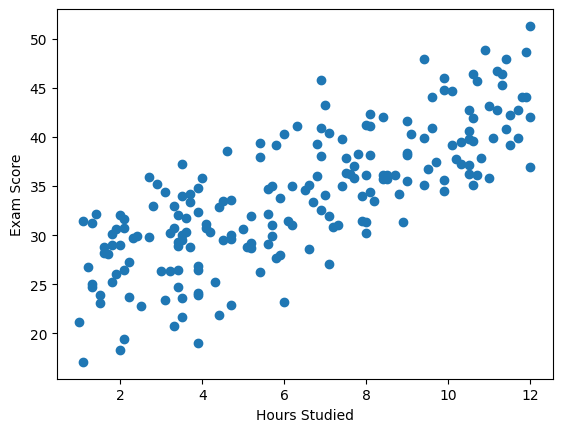

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df['hours_studied'], df['exam_score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['hours_studied','sleep_hours','attendance_percent','previous_scores']]
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

array([28.88607164, 29.68042066, 35.31195586, 31.18044826, 39.44894287,
       41.69158322, 23.96918347, 45.72250896, 41.6529321 , 27.47615681,
       26.09033959, 44.45348162, 27.22577144, 29.33836752, 36.53825172,
       34.75877399, 31.5395367 , 28.52996777, 40.3792585 , 29.84951368,
       21.85245583, 24.08822626, 27.61839558, 27.93331998, 35.96012145,
       43.8081039 , 34.91507705, 28.592239  , 37.57486402, 43.9712545 ,
       27.7683444 , 37.33910217, 37.03824477, 28.28799615, 42.6421297 ,
       21.64648068, 38.42517152, 36.15049022, 44.91531908, 35.47066788])

In [19]:
import pandas as pd

new_data = pd.DataFrame([[6,7,85,70]],
                        columns=['hours_studied','sleep_hours','attendance_percent','previous_scores'])

model.predict(new_data)

array([35.35323127])

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 2.310858235895833
R2 Score: 0.8537447137159516


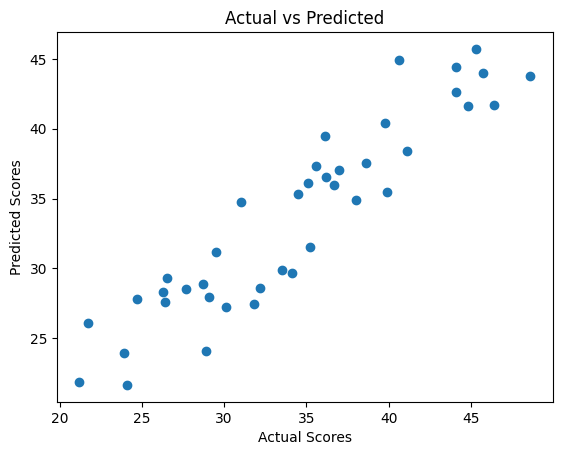

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

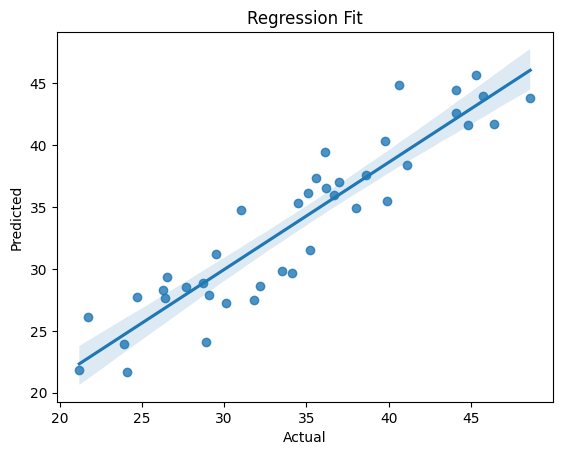

In [22]:
import seaborn as sns

sns.regplot(x=y_test, y=predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression Fit")
plt.show()

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression R2:", r2_score(y_test, predictions))
print("Random Forest R2:", r2_score(y_test, rf_pred))

print("Linear Regression MAE:", mean_absolute_error(y_test, predictions))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Linear Regression R2: 0.8537447137159516
Random Forest R2: 0.7922296358966725
Linear Regression MAE: 2.310858235895833
Random Forest MAE: 2.9697999999999993


<Axes: >

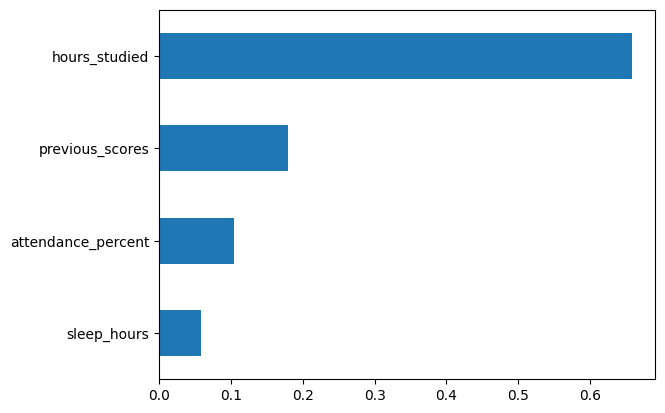

In [27]:
# Conclusion

print("Linear Regression performed better than Random Forest for this dataset.")
print("Reason: The dataset shows a linear relationship and is relatively small.")

Linear Regression performed better than Random Forest for this dataset.
Reason: The dataset shows a linear relationship and is relatively small.
